# Acoustic emission

A hydrophone measures the pressure that a bubble radiates, not its radius. Compute that pressure with `IncompressibleMonopole` and `QuasiAcoustic`, turn it into a Hann-windowed spectrum without aliasing, and map how the spectrum changes with drive pressure: harmonics at low pressure, then broadband noise once the bubble collapses inertially.

In [ ]:
# Install jbubble on Google Colab, or anywhere it's missing.
import importlib.util

if importlib.util.find_spec("jbubble") is None:
    %pip install --quiet "jbubble[examples]==0.2.0"

In [1]:
import os
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jbubble import SaveSpec, run_simulation
from jbubble.acoustics import IncompressibleMonopole, QuasiAcoustic
from jbubble.bubble.eom import KellerMiksis
from jbubble.bubble.gas import VanDerWaalsGas
from jbubble.bubble.medium import NewtonianMedium
from jbubble.bubble.shell import NoShell
from jbubble.pulse import ToneBurst, TukeyEnvelope
from jbubble.pulse.shapes import Sine
from jbubble.utils import GridSweep

plt.style.use("jbubble.style.light")
DRIVE_COLOUR = "#8c959f"  # the light theme's neutral grey for the drive

# JBUBBLE_QUICK=1 shrinks the pressure sweep for continuous integration (CI).
QUICK = os.environ.get("JBUBBLE_QUICK", "0") == "1"

The bubble is a 2 µm air bubble in water. A van der Waals gas with a hard core keeps violent collapses finite.

In [2]:
R0 = 2e-6  # equilibrium radius [m]
RHO_L, C_L = 998.0, 1500.0  # water density [kg/m³] and sound speed [m/s]
FREQ = 1e6  # drive frequency [Hz]

eom = KellerMiksis(
    gas=VanDerWaalsGas(gamma=1.4, h_frac=1 / 8.86),
    shell=NoShell(sigma=0.072),
    medium=NewtonianMedium(mu=1e-3, rho_L=RHO_L, c_L=C_L),
    R0=R0,
    P_amb=101325.0,
)

## Two emission models

Both models radiate the monopole pressure $p = \rho_L (2R\dot{R}^2 + R^2\ddot{R})/r$. `IncompressibleMonopole` assumes that sound travels instantly, which holds only within a small fraction of a wavelength, $r \ll c_L/f$ (1.5 mm at 1 MHz). `QuasiAcoustic` adds the travel time $r/c_L$: sample `i` reaches the hydrophone at `observer_time(result, r)[i] = result.ts[i] + r / c_L`.

A hydrophone 1 cm away hears the bubble 6.7 µs late. To record the whole signal on the simulation's clock, extend `t_max` past the end of the pulse by at least $r/c_L$. To put the delayed series on that clock, interpolate the radiated pressure itself, as the `QuasiAcoustic` documentation recommends.

In [3]:
r = 0.01  # hydrophone distance [m]
delay = r / C_L
pulse = ToneBurst(freq=FREQ, pressure=100e3, shape=Sine(), cycle_num=5)
t_max = pulse.t_end + delay

result = run_simulation(eom, pulse, save_spec=SaveSpec(num_samples=8192), t_max=t_max)

# Radiate into the same water that the simulation uses.
incompressible = IncompressibleMonopole(medium=eom.medium)
quasi = QuasiAcoustic(medium=eom.medium)
p_inc = incompressible(result, r)
p_quasi = quasi(result, r)
t_arrival = quasi.observer_time(result, r)
p_heard = jnp.interp(result.ts, t_arrival, p_quasi, left=0.0)

print(f"Travel time r/c_L = {delay * 1e6:.2f} µs; simulated to {t_max * 1e6:.1f} µs")
print(f"Peak radiated pressure at 1 cm: {float(jnp.max(jnp.abs(p_quasi))):.0f} Pa")

# The monopole falls off as 1/r, so r * p is the same at every distance.
distances = jnp.array([0.005, 0.01, 0.05])
peaks = jax.vmap(lambda d: jnp.max(jnp.abs(quasi(result, d))))(distances)
for d, peak in zip(distances, peaks, strict=True):
    print(f"  r = {float(d) * 1e3:4.0f} mm: r * max|p| = {float(d * peak):.3f} Pa m")

Travel time r/c_L = 6.67 µs; simulated to 16.7 µs
Peak radiated pressure at 1 cm: 328 Pa


  r =    5 mm: r * max|p| = 3.283 Pa m
  r =   10 mm: r * max|p| = 3.283 Pa m
  r =   50 mm: r * max|p| = 3.283 Pa m


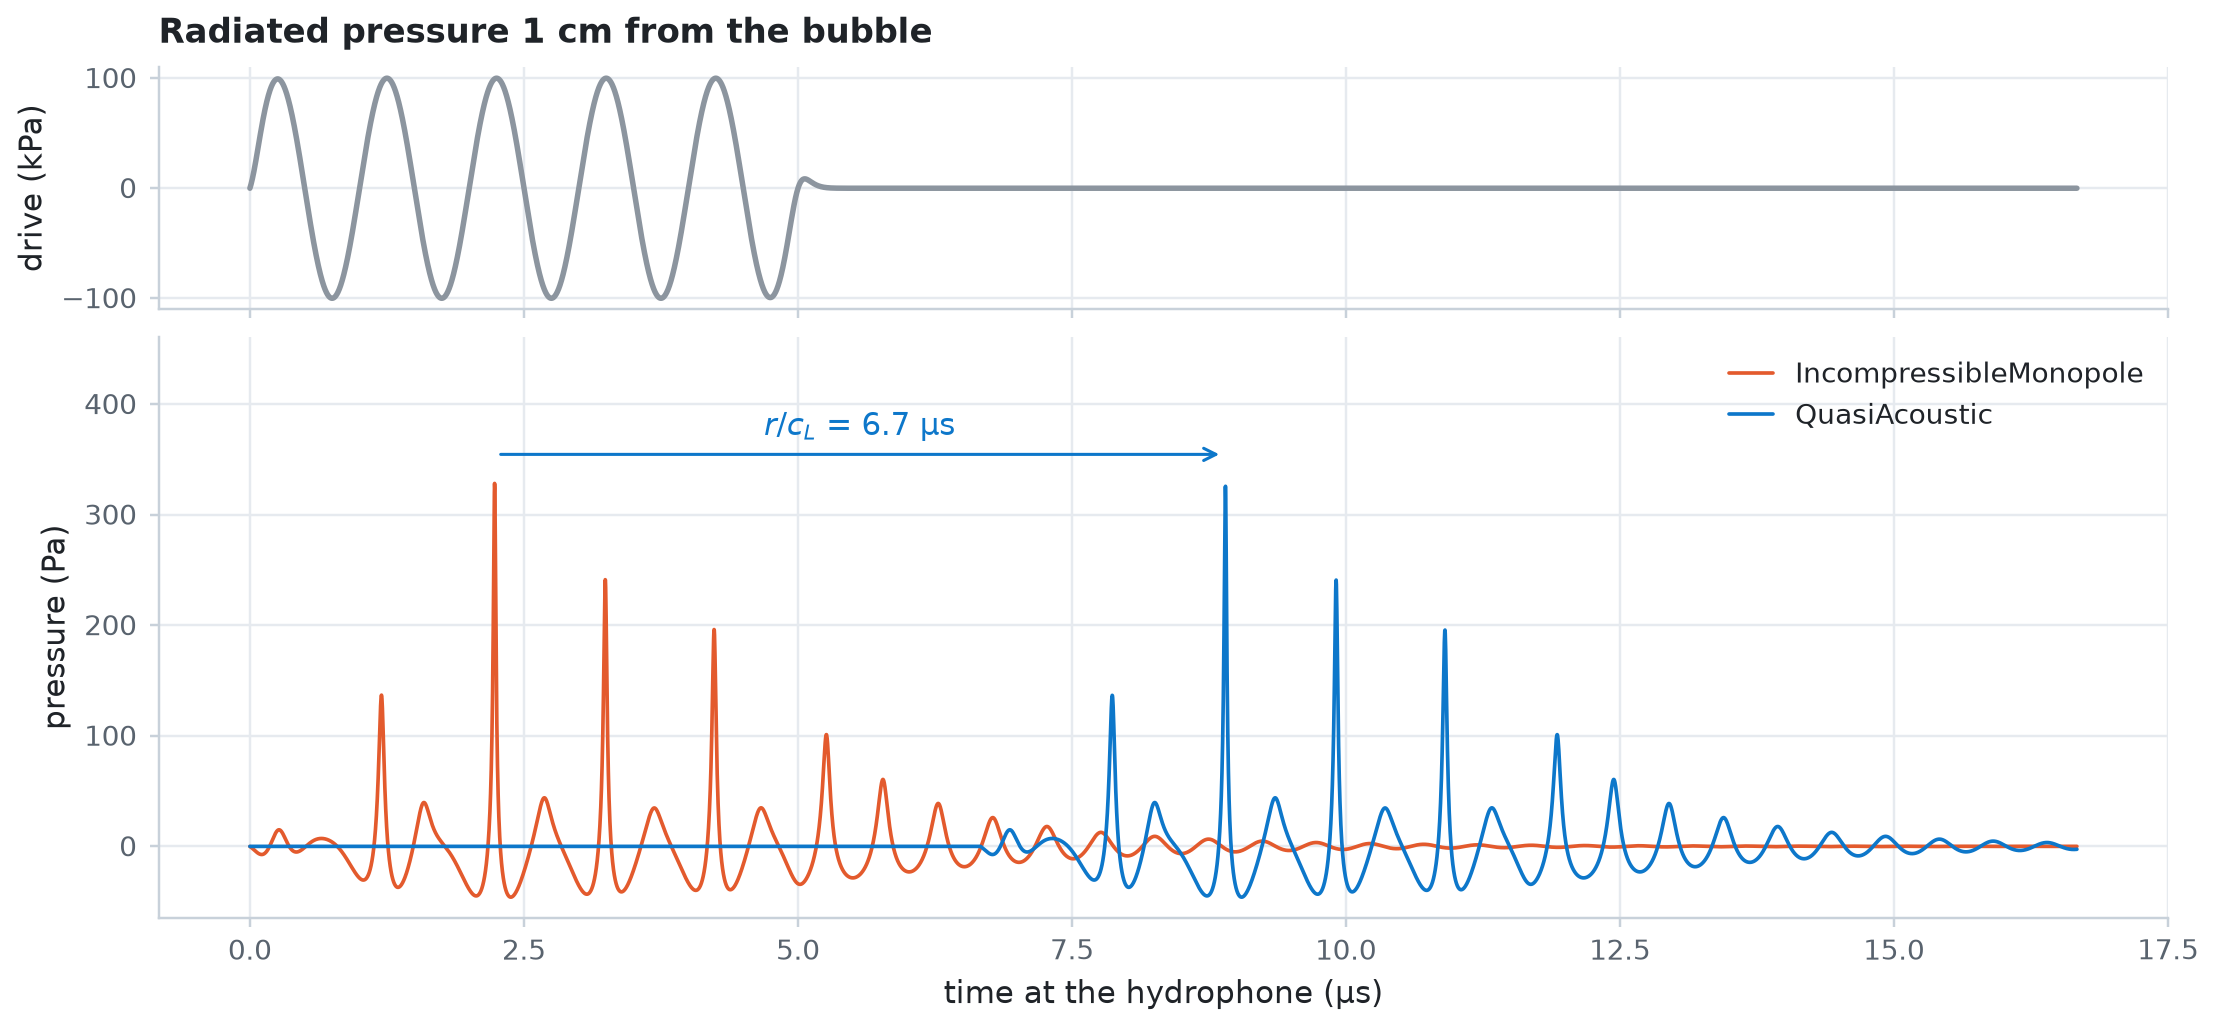

In [4]:
fig, (ax_drive, ax_p) = plt.subplots(
    2, 1, figsize=(10, 4.6), sharex=True, height_ratios=[1, 2.4], layout="constrained"
)
t_us = np.asarray(result.ts) * 1e6
ax_drive.plot(t_us, np.asarray(result.driving_pressure) / 1e3, color=DRIVE_COLOUR)
ax_drive.set_ylabel("drive (kPa)")
ax_drive.set_title("Radiated pressure 1 cm from the bubble")
ax_p.plot(t_us, np.asarray(p_inc), color="C1", lw=1.2, label="IncompressibleMonopole")
ax_p.plot(t_us, np.asarray(p_heard), color="C0", lw=1.2, label="QuasiAcoustic")
# Mark the delay between the two models' largest peaks.
t_peak = float(result.ts[jnp.argmax(p_inc)]) * 1e6
y_arrow = 1.08 * float(jnp.max(p_inc))
ax_p.annotate(
    "",
    xy=(t_peak + delay * 1e6, y_arrow),
    xytext=(t_peak, y_arrow),
    arrowprops={"arrowstyle": "->", "color": "C0"},
)
ax_p.text(
    t_peak + delay * 1e6 / 2,
    1.03 * y_arrow,
    f"$r/c_L$ = {delay * 1e6:.1f} µs",
    color="C0",
    ha="center",
    va="bottom",
)
ax_p.set_ylim(top=1.3 * y_arrow)
ax_p.set_xlabel("time at the hydrophone (µs)")
ax_p.set_ylabel("pressure (Pa)")
ax_p.legend(loc="upper right")
plt.show()

## A spectrum without aliasing

The spectrum of the radiated pressure shows what the bubble adds to the drive. Drive it with a 20-cycle tone burst whose flat top (a Tukey envelope) holds the pressure steady, record 24 µs, and apply a Hann window before the fast Fourier transform (FFT). The levels are in dB re 1 Pa at 1 m: the radiated pressure times the distance.

An inertial collapse radiates a spike less than a nanosecond wide. The saved samples are point values, so content above the Nyquist frequency folds back into the band you look at. With 4096 samples over 24 µs, one every 5.9 ns, the folded spike energy fills the spectrum with false broadband noise. With 131 072 samples, one every 0.18 ns, the spectrum up to 8 MHz changes by less than 1 dB when you double the sample count.

In [5]:
T_RECORD = 24e-6  # record length [s]
F_MAX = 8e6  # highest frequency to keep [Hz]
N_DENSE = 131_072
N_COARSE = 4096


def spectrum(pressure, num_samples):
    """Return the Hann-windowed level [dB re 1 Pa at 1 m] up to F_MAX, and R_max/R0."""
    burst = ToneBurst(
        freq=FREQ,
        pressure=pressure,
        shape=Sine(),
        cycle_num=20,
        envelope=TukeyEnvelope(alpha=0.25),
    )
    res = run_simulation(
        eom, burst, save_spec=SaveSpec(num_samples=num_samples), t_max=T_RECORD
    )
    p = quasi(res, 1.0)  # r * p, the pressure referred to 1 m
    window = jnp.hanning(num_samples)
    amplitude = jnp.abs(jnp.fft.rfft((p - p.mean()) * window)) * 2 / window.sum()
    n_keep = int(F_MAX * T_RECORD) + 1  # FFT bins are 1 / T_RECORD apart
    return {
        "level": 20 * jnp.log10(amplitude[:n_keep] + 1e-12),
        "expansion": res.radius.max() / R0,
        "converged": res.converged,
    }


freqs = np.arange(int(F_MAX * T_RECORD) + 1) / T_RECORD
dense = jax.jit(spectrum, static_argnums=1)
stable = dense(100e3, N_DENSE)
inertial = dense(250e3, N_DENSE)
aliased = jax.jit(spectrum, static_argnums=1)(250e3, N_COARSE)
error = np.abs(np.asarray(aliased["level"] - inertial["level"]))
print(
    f"R_max/R0: {float(stable['expansion']):.2f} at 100 kPa, "
    f"{float(inertial['expansion']):.2f} at 250 kPa"
)
print(f"With 4096 samples, the 250 kPa spectrum is off by up to {error.max():.0f} dB")

R_max/R0: 1.56 at 100 kPa, 3.99 at 250 kPa
With 4096 samples, the 250 kPa spectrum is off by up to 47 dB


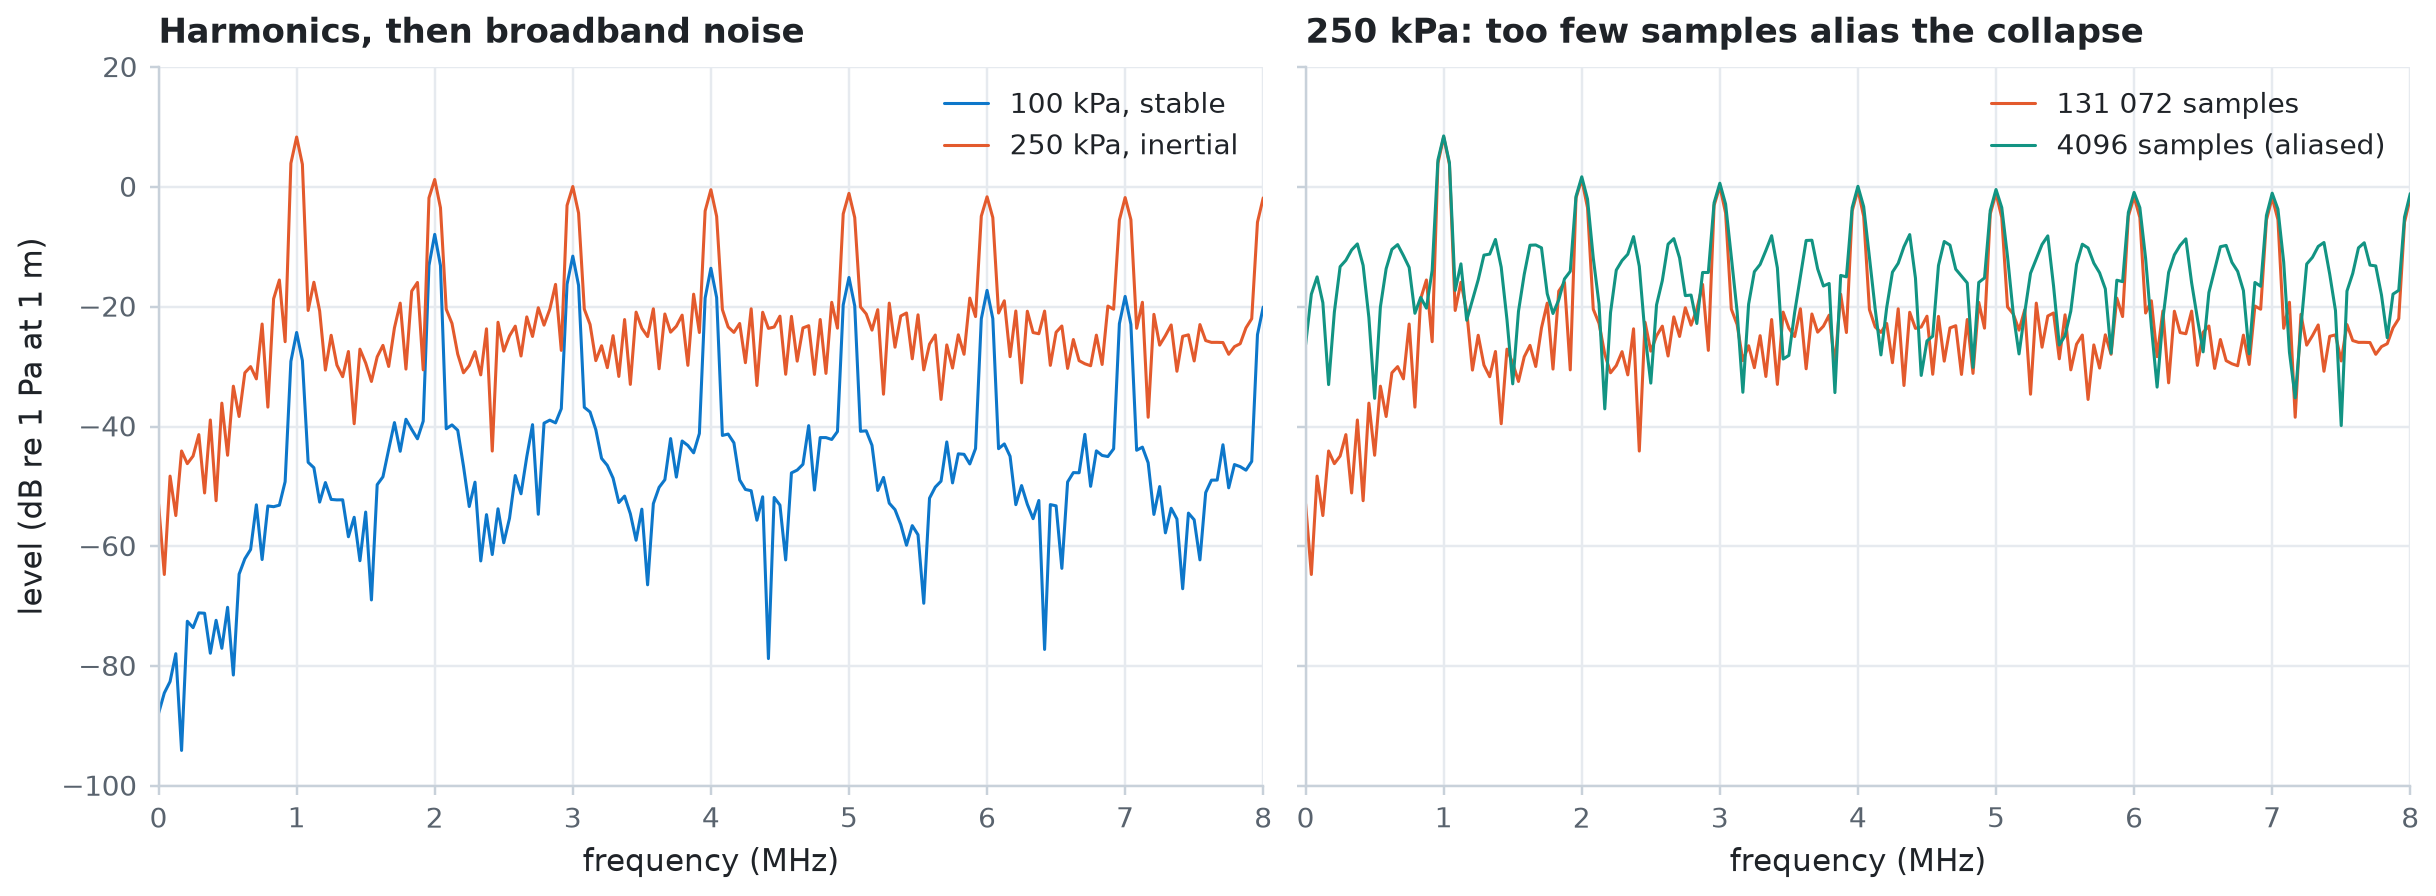

In [6]:
fig, (ax_a, ax_b) = plt.subplots(
    1, 2, figsize=(11, 4), sharey=True, layout="constrained"
)
f_mhz = freqs / 1e6
ax_a.plot(f_mhz, np.asarray(stable["level"]), color="C0", lw=1, label="100 kPa, stable")
ax_a.plot(
    f_mhz, np.asarray(inertial["level"]), color="C1", lw=1, label="250 kPa, inertial"
)
ax_a.set_title("Harmonics, then broadband noise")
ax_b.plot(
    f_mhz, np.asarray(inertial["level"]), color="C1", lw=1, label="131 072 samples"
)
ax_b.plot(
    f_mhz,
    np.asarray(aliased["level"]),
    color="C2",
    lw=1,
    label="4096 samples (aliased)",
)
ax_b.set_title("250 kPa: too few samples alias the collapse")
for ax in (ax_a, ax_b):
    ax.set_xlabel("frequency (MHz)")
    ax.set_xlim(0, F_MAX / 1e6)
    ax.legend(loc="upper right")
ax_a.set_ylim(-100, 20)
ax_a.set_ylabel("level (dB re 1 Pa at 1 m)")
plt.show()

## Spectrum map against drive pressure

Sweep the drive pressure with `GridSweep`, keeping only the bins up to 8 MHz from each simulation. Each one stores 131 072 samples, so a small `batch_size` keeps few of them in memory at a time.

The broadband floor is the median level between the spectral lines, at odd multiples of $f/4$ (0.25, 0.75, 1.25 MHz, and so on), which lie between the harmonics, the subharmonic $f/2$, and the ultraharmonics $3f/2, 5f/2, \ldots$ Take the broadband threshold as the lowest pressure at which the floor comes within 10 dB of its level under the strongest drives. Compare it with the radial criterion for inertial cavitation, $R_\max/R_0 \geq 2$.

In [7]:
pressures = jnp.linspace(20e3, 400e3, 32 if QUICK else 96)
sweep = GridSweep(
    lambda pressure: spectrum(pressure, N_DENSE),
    {"pressure": pressures},
    batch_size=16,
    progress=False,
)
t0 = time.perf_counter()
spectra = sweep.run()
print(
    f"{pressures.size} pressures in {time.perf_counter() - t0:.1f} s; "
    f"all converged: {bool(spectra['converged'].all())}"
)

between_lines = np.zeros(freqs.size, dtype=bool)
for k in range(1, int(4 * F_MAX / FREQ), 2):
    between_lines |= np.abs(freqs - k * FREQ / 4) <= 50e3
floor = np.median(spectra["level"][:, between_lines], axis=1)
strong = np.median(floor[-len(floor) // 4 :])
p_kpa = np.asarray(pressures) / 1e3
p_broadband = p_kpa[np.argmax(floor >= strong - 10)]
p_inertial = p_kpa[np.argmax(spectra["expansion"] >= 2)]
print(f"Broadband threshold:           {p_broadband:.0f} kPa")
print(f"First pressure with R_max/R0 >= 2: {p_inertial:.0f} kPa")

96 pressures in 17.3 s; all converged: True
Broadband threshold:           148 kPa
First pressure with R_max/R0 >= 2: 148 kPa


The spectral and the radial criteria agree to within one pressure step: broadband emission starts where the bubble first expands to twice its equilibrium radius. Above that pressure, the gaps between the spectral lines fill with noise.

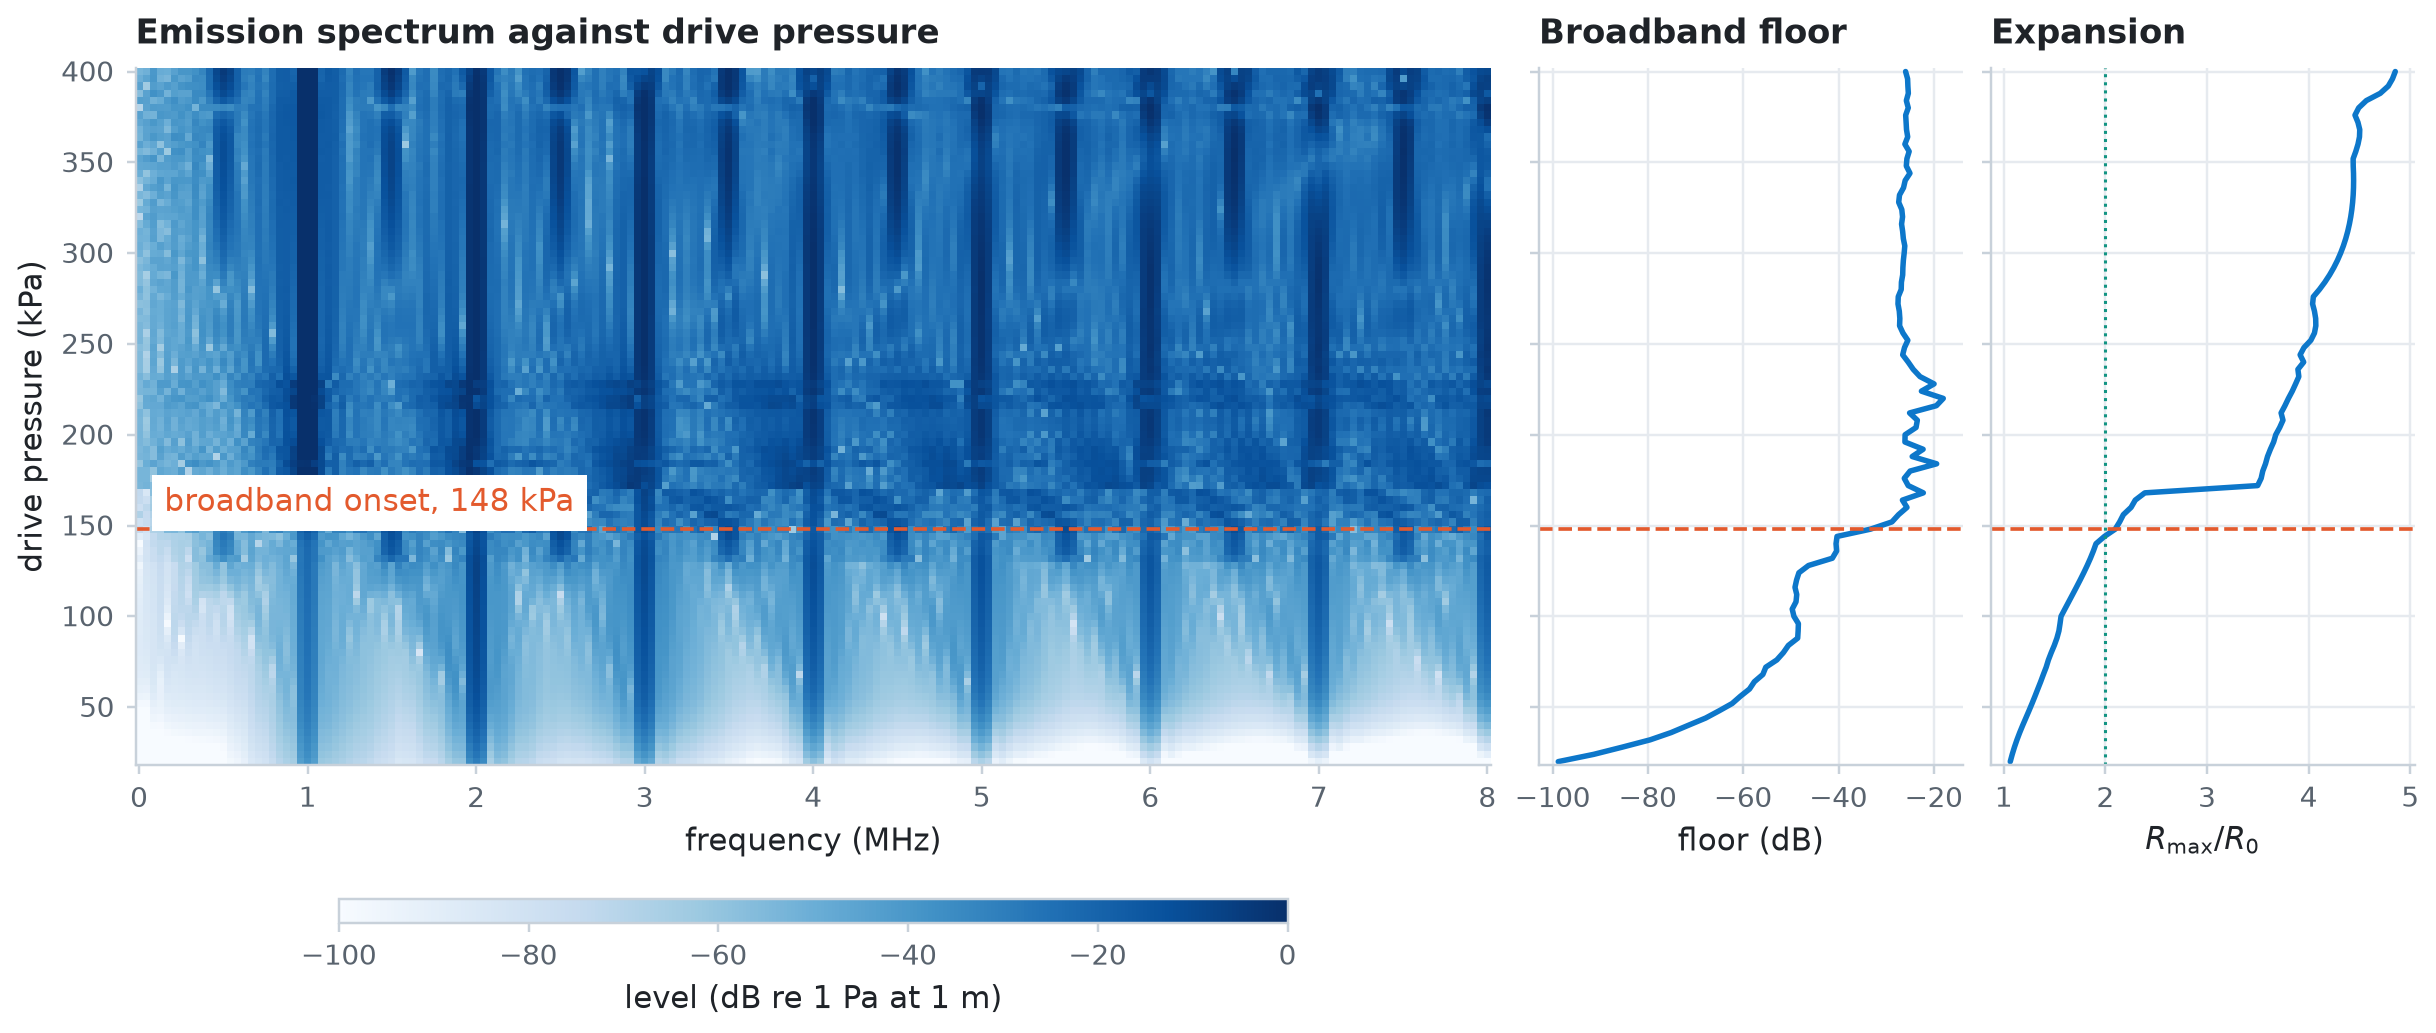

In [8]:
fig, (ax_map, ax_floor, ax_exp) = plt.subplots(
    1,
    3,
    figsize=(11, 4.6),
    sharey=True,
    width_ratios=[3.2, 1, 1],
    layout="constrained",
)
mesh = ax_map.pcolormesh(
    f_mhz, p_kpa, spectra["level"], shading="nearest", vmin=-100, vmax=0
)
fig.colorbar(
    mesh,
    ax=ax_map,
    location="bottom",
    shrink=0.7,
    aspect=40,
    label="level (dB re 1 Pa at 1 m)",
)
ax_map.set_xlabel("frequency (MHz)")
ax_map.set_ylabel("drive pressure (kPa)")
ax_map.set_title("Emission spectrum against drive pressure")

ax_floor.plot(floor, p_kpa, color="C0")
ax_floor.set_xlabel("floor (dB)")
ax_floor.set_title("Broadband floor")
ax_exp.plot(spectra["expansion"], p_kpa, color="C0")
ax_exp.axvline(2, color="C2", ls=":", lw=1)
ax_exp.set_xlabel("$R_\\max/R_0$")
ax_exp.set_title("Expansion")
for ax in (ax_map, ax_floor, ax_exp):
    ax.axhline(p_broadband, color="C1", ls="--", lw=1.2)
ax_map.text(
    0.15,
    p_broadband + 6,
    f"broadband onset, {p_broadband:.0f} kPa",
    color="C1",
    va="bottom",
    bbox={"facecolor": plt.rcParams["axes.facecolor"], "edgecolor": "none"},
)
plt.show()